# 03 · Analysis of one take

Masks → spectrogram → band levels relative to baseline → spectra before/after (and the *excess*) →
onset → events and trigger rate → detector check → figures saved.

Everything here reads the cached bundle, so it is fast. Re-run cells freely.

In [1]:
# ==== YOUR SETTINGS ====
CONFIG = "../config/demo.yaml"
TAKE = "DEMO_002"
BASELINE = (5.0, 34.0)            # [s] quiet reference window BEFORE anything is added
AFTER = (60.0, 170.0)             # [s] window to compare with the baseline
MARKERS = {"drop": 35.0, "acid": 40.0}   # events you noted in the lab book (s from take start)
FMAX = 24000                      # highest frequency to show [Hz]
REF_CHANNEL_FOR_CHIRPS = 4        # the channel that hears the active source best (air mic)
FIND_CHIRPS = False               # True: locate a periodic source automatically and mask it
CHIRP_PERIOD_S = 10.0             # known period from the signal-generator log (None = fit it)

In [2]:
# ---- standard setup (same in every notebook) ----
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import zoom_acoustics as za
from zoom_acoustics import plots as zp, dsp

cfg = za.load_config(CONFIG)
print("config   :", cfg.config_file)
print("data_dir :", cfg.data_dir)
print("cache_dir:", cfg.cache_dir)
print("figures  :", cfg.figures_dir)

config   : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/config/demo.yaml
data_dir : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/audio
cache_dir: /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/cache
figures  : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures


In [3]:
f = za.load_features(cfg, TAKE)
print(f.take, f"{f.duration_s:.1f} s", "channels", f.channels, "sr", f.sr)
print("masks from config:", len(f.mask_windows), "windows")

DEMO_002 180.0 s channels [1, 2, 3, 4] sr 48000
masks from config: 18 windows


## 1. Masks (active chirps, known disturbances)

If a periodic active source was running, every passive number must exclude it. Either put it in the
config (`takes: <take>: periodic: {...}`) **before** processing (best: the detector then ignores it too),
or find it here and add it after the fact. Grey bands in every plot are masked time.

In [4]:
if FIND_CHIRPS and REF_CHANNEL_FOR_CHIRPS in f.channels:
    g = za.masks.find_periodic_bursts(f.t_level, f.level(REF_CHANNEL_FOR_CHIRPS, "broadband"),
                                      period_s=CHIRP_PERIOD_S)
    print(g)
    if g:
        # the chirp sweep starts at 100 Hz; pad generously before the detected rise
        f.add_masks(za.masks.periodic_windows(g["first_s"], g["period_s"], f.duration_s,
                                              pad_before_s=0.5, pad_after_s=1.5))
live = za.masks.live_seconds(0, f.duration_s, f.mask_windows)
print(f"masked: {100*(1-live/f.duration_s):.1f} % of the take")

masked: 16.5 % of the take


## 2. Spectrogram

[PosixPath('/media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures/DEMO_002_spectrogram.png')]

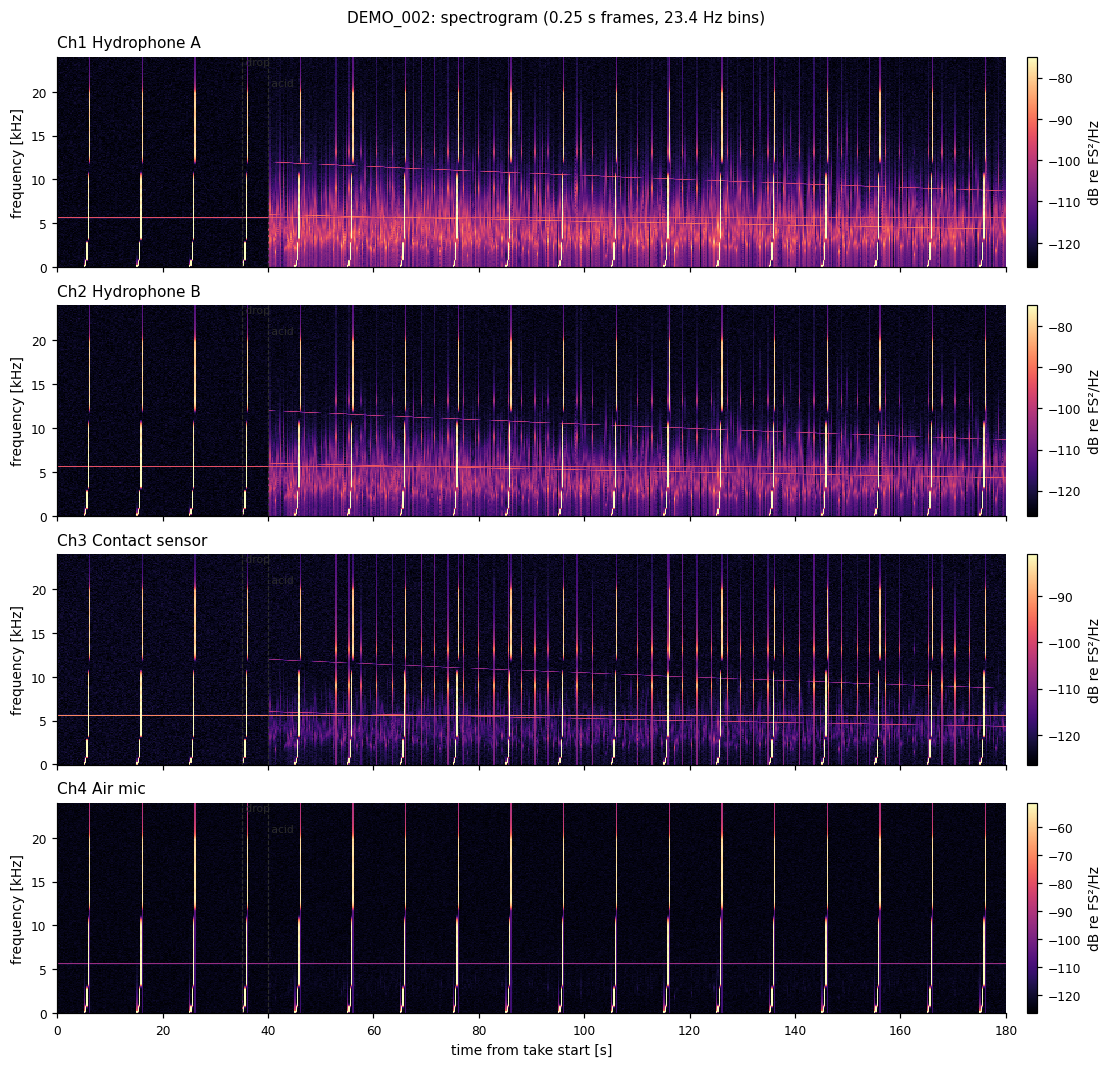

In [5]:
fig = zp.plot_spectrogram(f, fmax=FMAX, markers=MARKERS)
zp.save(fig, cfg, f"{TAKE}_spectrogram")

### Full range + automatic zooms, and a difference image

`clim=(lo, hi)` fixes the colour range, so use the same values for every take you compare.
`background=` turns the picture into a **difference image** against a quiet part: white = unchanged,
red = added. For a separate background take, pass `background_feat=za.load_features(cfg, "<take>")`.
`units="pa"` shows dB re 1 µPa²/Hz if the channel has `pa_per_fs` in the config.

In [6]:
take = za.find_take(za.discover_takes(cfg.data_dir, recursive=cfg.recursive, pattern=cfg.file_pattern), TAKE)
CH = f.channels[0]
zooms = za.views.suggest_zooms(f, CH, baseline=BASELINE, fmax=FMAX)
pd.DataFrame([{k: v for k, v in z.items() if k != "track"} for z in zooms])

,name,t0,t1,f0,f1,why,kind
0,baseline,5.00000,34.00000,0.0,24000,quiet reference window,NaN
1,onset,30.12500,70.12500,0.0,24000,sustained +6 dB rise at 40.1 s,NaN
2,loudest,50.00000,80.00000,0.0,24000,30 s with the highest audio-band level,NaN
3,transient,157.88975,158.13975,0.0,24000,strongest trigger at 157.940 s,raw


[PosixPath('/media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures/DEMO_002_overview_zoom.png')]

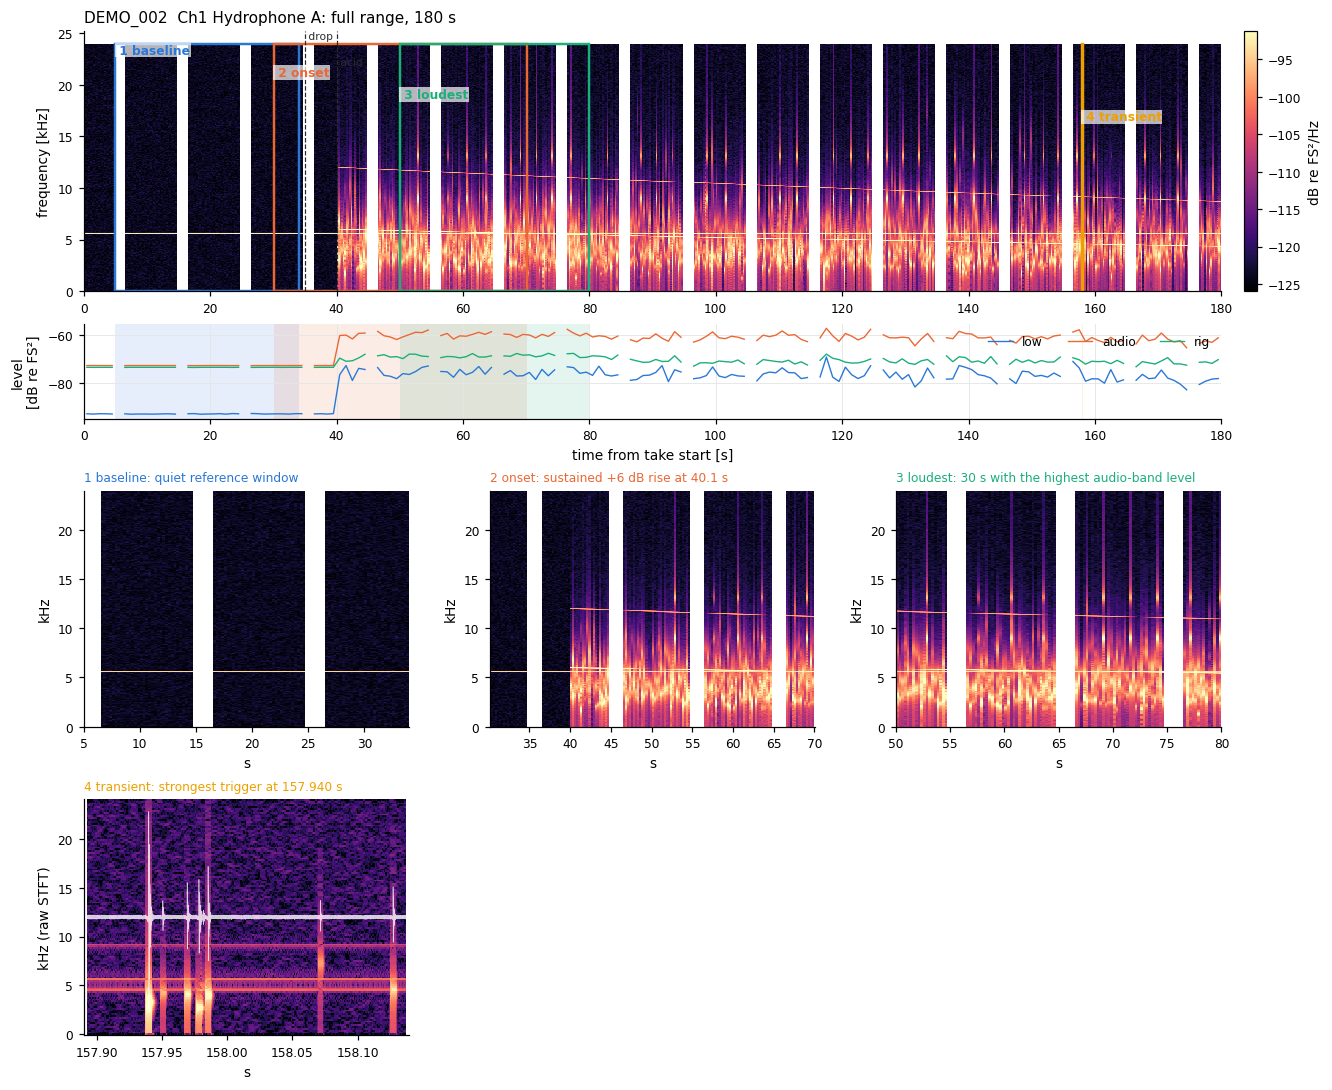

In [7]:
fig = za.views.plot_overview_zoom(f, CH, zooms, take=take, fmax=FMAX, markers=MARKERS)
zp.save(fig, cfg, f"{TAKE}_overview_zoom")

[PosixPath('/media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures/DEMO_002_difference.png')]

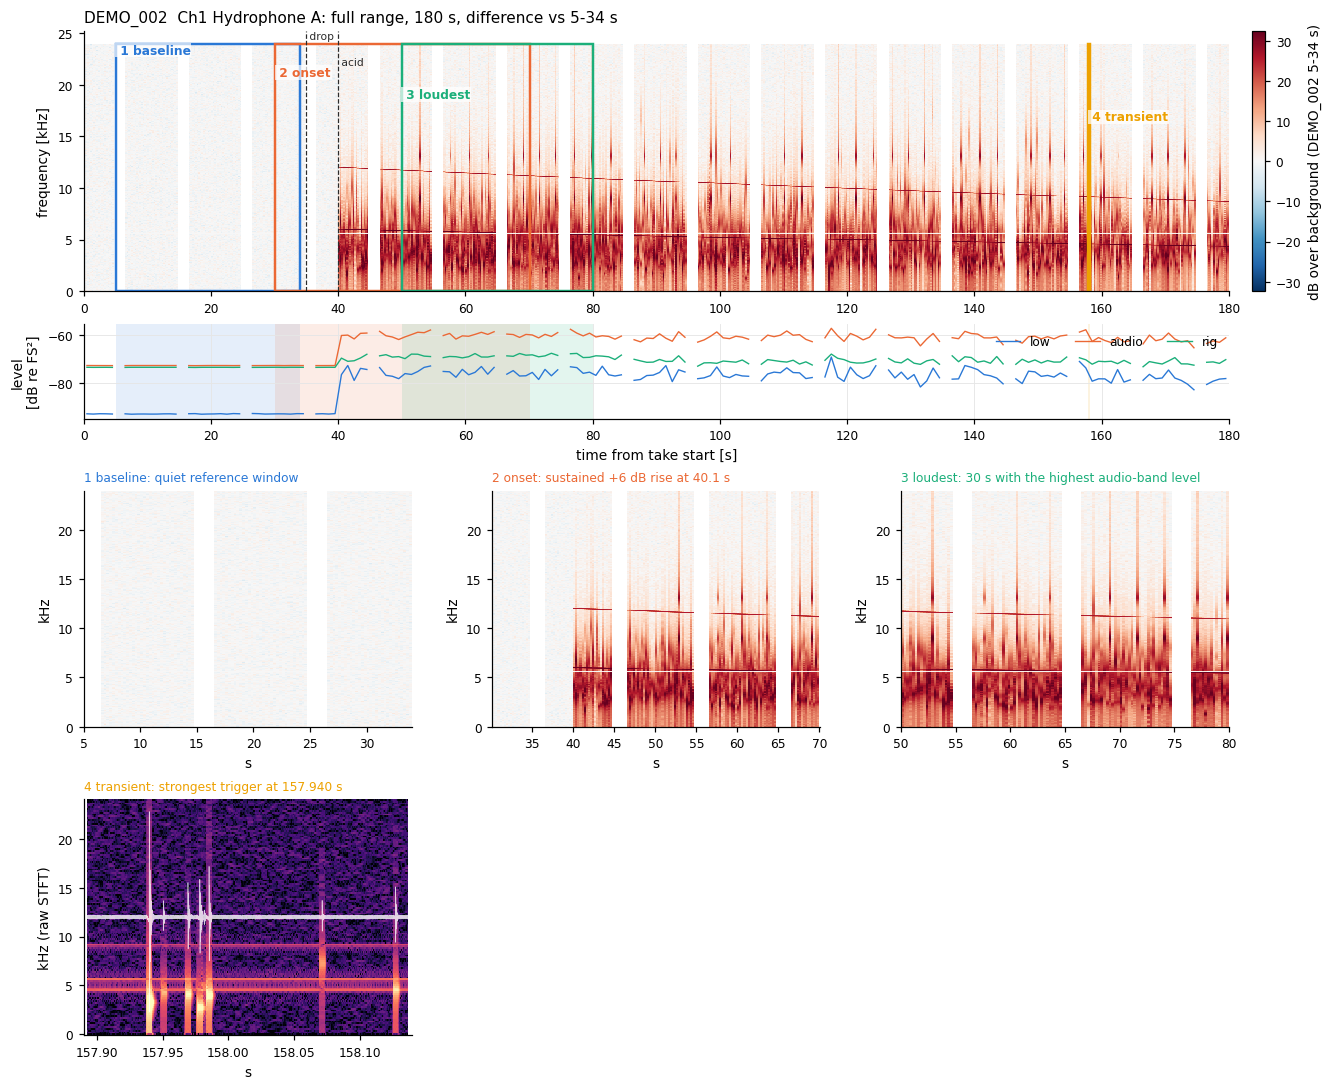

In [8]:
fig = za.views.plot_overview_zoom(f, CH, zooms, take=take, fmax=FMAX, markers=MARKERS, background=BASELINE)
zp.save(fig, cfg, f"{TAKE}_difference")

Zoom by hand anywhere: a list of boxes `dict(name, t0, t1, f0, f1, why)`, or a single raw-audio view of
one event.

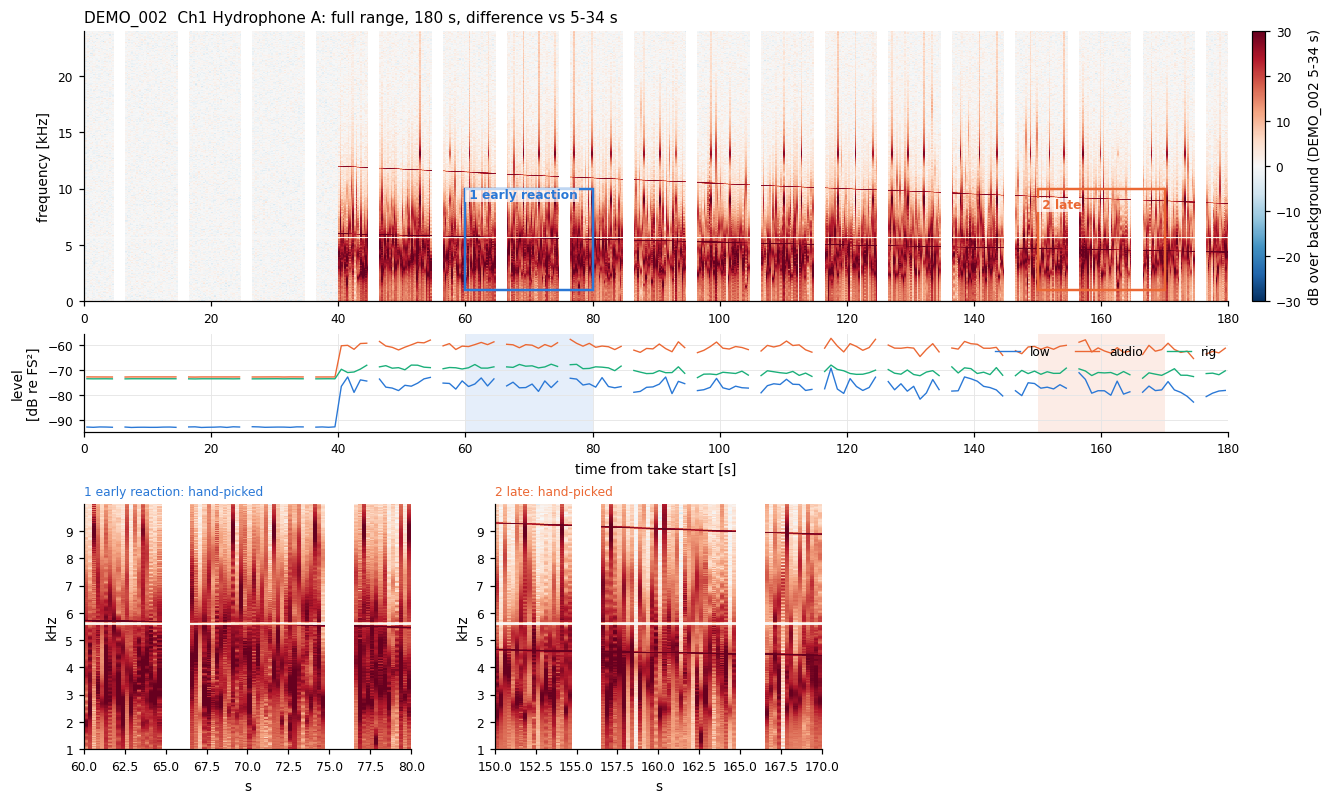

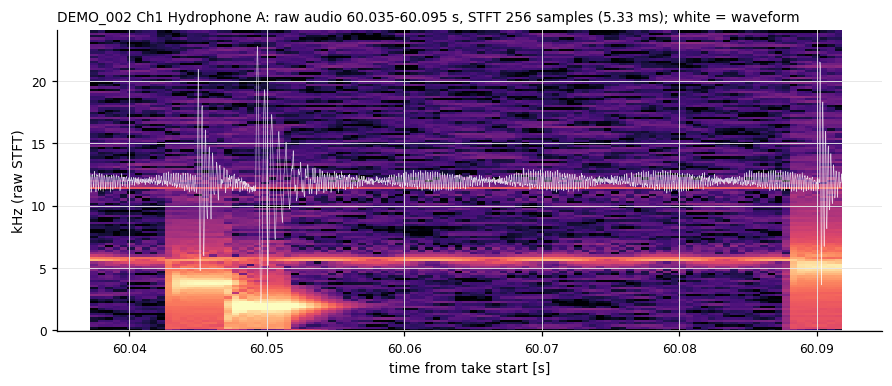

In [9]:
my_zooms = [dict(name="early reaction", t0=AFTER[0], t1=AFTER[0] + 20, f0=1000, f1=10000, why="hand-picked"),
            dict(name="late", t0=AFTER[1] - 20, t1=AFTER[1], f0=1000, f1=10000, why="hand-picked")]
fig = za.views.plot_overview_zoom(f, CH, my_zooms, fmax=FMAX, background=BASELINE, clim=(-30, 30))
ev = f.events[(f.events.channel == CH) & (f.events.t_s > AFTER[0])]
if len(ev):
    t_ev = float(ev.t_s.iloc[0])
    fig = za.views.plot_raw_zoom(take, CH, t_ev - 0.01, t_ev + 0.05, fmax=FMAX, cfg=cfg)

## 3. Band levels, as change relative to the baseline

Absolute dB values are **uncalibrated** (dB re digital full scale) and differ between sensors for
reasons unrelated to the sample. The change relative to a quiet baseline, within one channel, is the robust quantity.

[PosixPath('/media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures/DEMO_002_levels.png')]

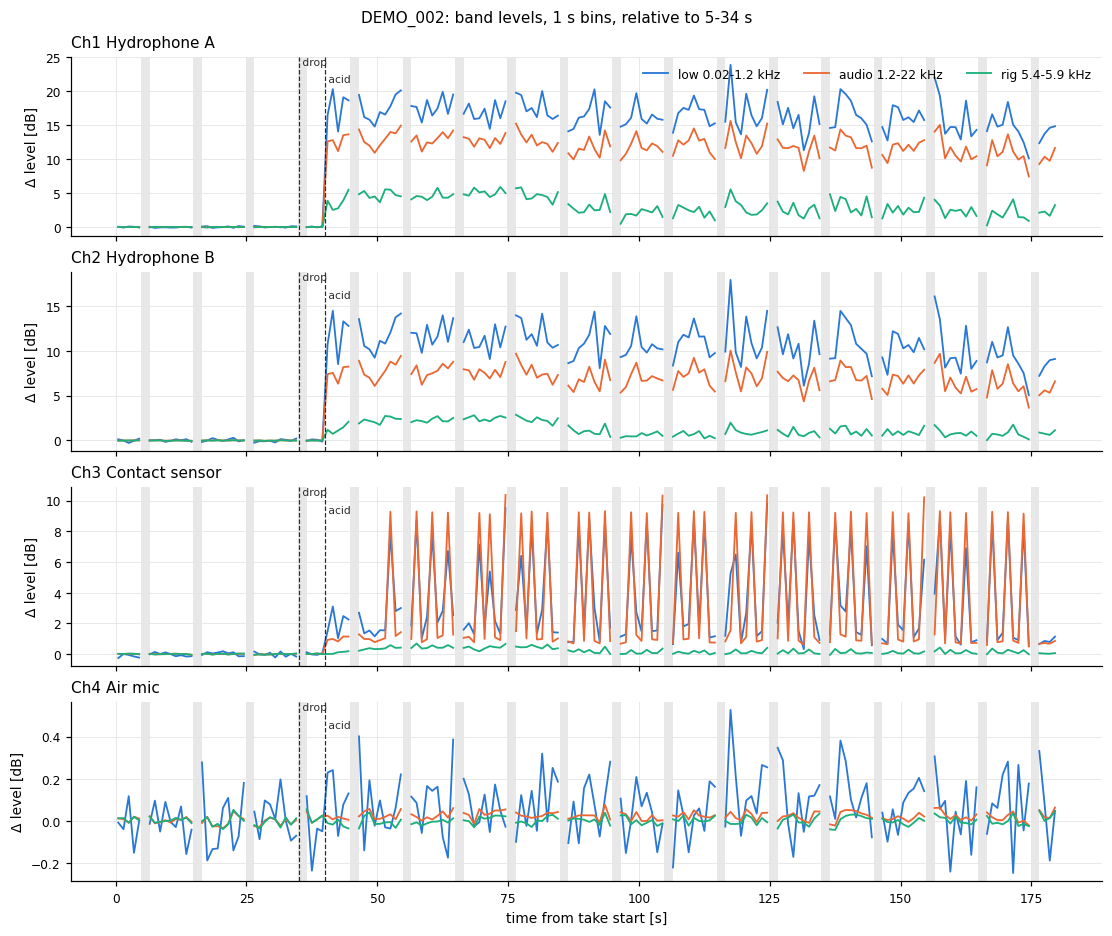

In [10]:
bands = [b for b in ("low", "audio", "rig", "hb1", "hb2", "hb3") if b in f.bands]
fig = zp.plot_levels(f, bands=bands, dt=1.0, markers=MARKERS, relative_to=BASELINE)
zp.save(fig, cfg, f"{TAKE}_levels")

## 4. Spectra: baseline vs after, and the excess

The dotted line is `after − baseline` in **linear power**: the spectrum of what was *added*. Grey = the
`rig` band (a 5.6 kHz apparatus resonance in the Sep-2026 setup; check whether yours has one in a
water-only take).

[PosixPath('/media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures/DEMO_002_spectra.png')]

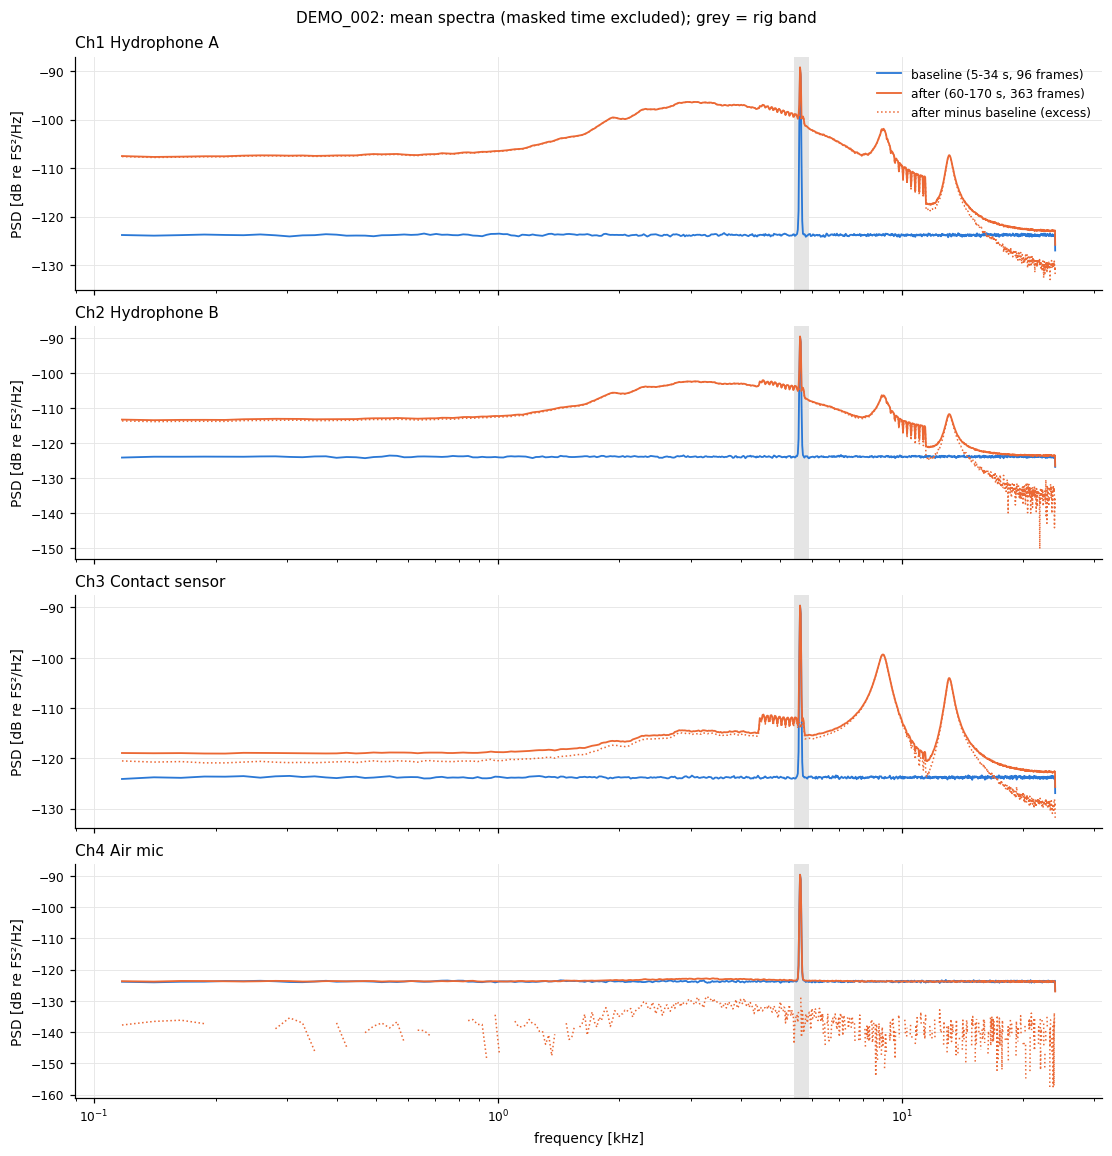

In [11]:
fig = zp.plot_psd(f, {"baseline": BASELINE, "after": AFTER}, fmax=FMAX, fmin=100, excess=True)
zp.save(fig, cfg, f"{TAKE}_spectra")

## 5. Onset

First time the audio-band level rises 6 dB above baseline **and stays up** for 10 s. The hold
requirement is what rejects a single knock or the sample being dropped in.

In [12]:
rows = []
for c in f.channels:
    on, base = f.onset(c, "audio", base_window=BASELINE, rise_db=6, hold_s=10)
    rows.append(dict(channel=c, label=f.label(c), onset_s=on, baseline_dB=dsp.db(base)))
onsets = pd.DataFrame(rows); onsets

,channel,label,onset_s,baseline_dB
0,1,Ch1 Hydrophone A,40.125,-72.702065
1,2,Ch2 Hydrophone B,47.875,-72.704685
2,3,Ch3 Contact sensor,NaN,-72.711842
3,4,Ch4 Air mic,NaN,-72.710923


## 6. Events (STA/LTA triggers) and trigger rate

A trigger is a short transient that stands out from the preceding 60 ms. **A trigger rate is not a
bubble rate:** at high bubble rates triggers merge and the LTA is inflated, so the rate saturates
(see `docs/VALIDATION.md`, R1/R2). Compare rates within a channel, over time.

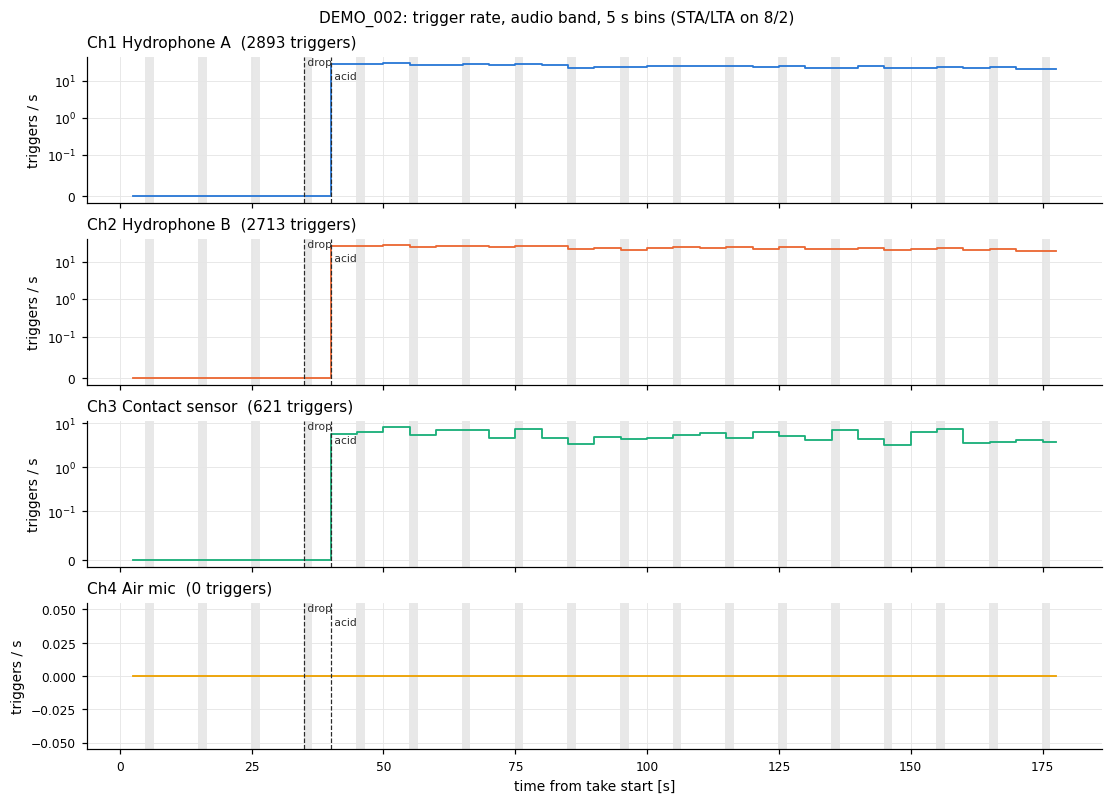

In [13]:
det = f.meta["detect_bands"][0] if f.meta["detect_bands"] else None
if det:
    fig = zp.plot_event_rate(f, det, bin_s=5.0, markers=MARKERS)
    zp.save(fig, cfg, f"{TAKE}_trigger_rate")

### Check the detector by eye

Before trusting any count, look at what the detector saw in a short window: envelope, STA/LTA ratio,
thresholds and the triggers. Pick a window inside the reaction.

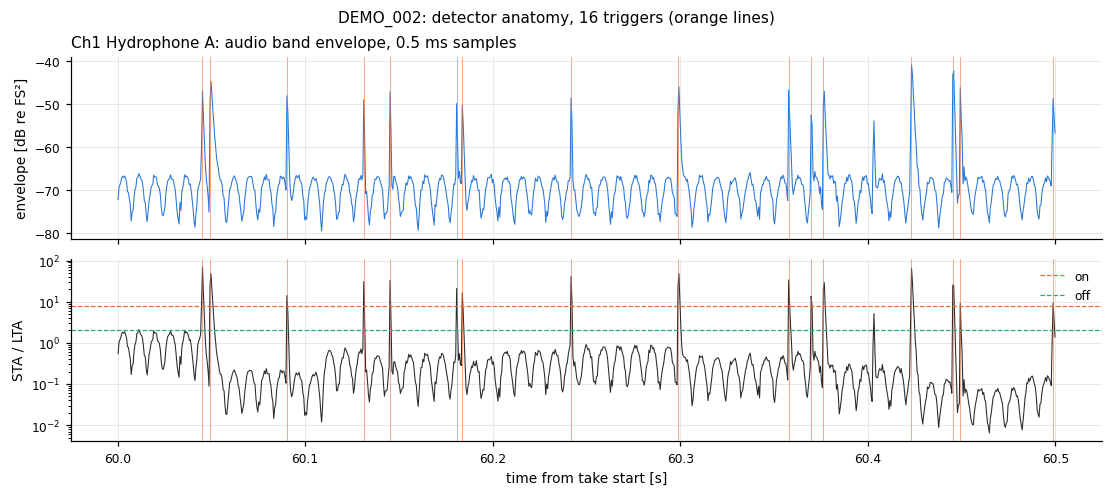

In [14]:
if det and f.meta["env_stored"]:
    ch0 = f.channels[0]
    t_chk = (AFTER[0], AFTER[0] + 0.5)
    fig = zp.plot_detector(f, ch0, det, *t_chk)

### Re-run the detector with other settings (no need to re-process)

Only possible when the fine envelope was stored (`env_stored` is True).

In [15]:
if det and f.meta["env_stored"]:
    for on in (5, 8, 12):
        ev, live = f.redetect(f.channels[0], det, on=on)
        print(f"on={on:>2}: {len(ev)} triggers, {len(ev)/live:.1f} per live second")

on= 5: 3180 triggers, 21.2 per live second
on= 8: 2893 triggers, 19.3 per live second
on=12: 2557 triggers, 17.1 per live second


## 7. Summary table for this take

In [16]:
tab = za.timeline.window_table([f], {"baseline": BASELINE, "after": AFTER}, bands=bands)
tab.pivot_table(index=["channel", "label"], columns=["band", "window"], values="level_dB").round(1)

band                       audio            low            rig         
window                     after baseline after baseline after baseline
channel label                                                          
1       Ch1 Hydrophone A   -60.4    -72.7 -75.9    -93.0 -70.2    -73.4
2       Ch2 Hydrophone B   -65.4    -72.7 -81.6    -93.0 -72.2    -73.4
3       Ch3 Contact sensor -66.9    -72.7 -87.9    -92.9 -73.2    -73.5
4       Ch4 Air mic        -72.7    -72.7 -92.9    -93.0 -73.4    -73.4

In [17]:
tab[tab["window"] == "after"].pivot_table(index=["channel", "label"], columns="band", values="delta_dB").round(1)

,band,audio,low,rig
channel,label,,,
1,Ch1 Hydrophone A,12.3,17.1,3.3
2,Ch2 Hydrophone B,7.3,11.4,1.3
3,Ch3 Contact sensor,5.8,5.1,0.2
4,Ch4 Air mic,0.0,0.1,0.0


## 8. Save the standard figure set

One call writes every standard figure for this take (overview + zooms, difference image, waveforms,
spectrogram, levels, spectra, trigger rate, detector, inter-event gaps, glide, glide interpretation) plus a
summary CSV and an `INDEX.md` page describing each figure, into `figures_dir/<take>_figure_set/`.
Examples for real data are in `examples/`.

In [18]:
paths, summ = za.report.save_figure_set(cfg, TAKE, baseline=BASELINE, after=AFTER, markers=MARKERS,
                                        fmax=FMAX, glide_seed=(4000, 8000))
print("wrote", len(paths), "files to", paths[0].parent)
summ.round(2)

wrote 12 files to /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures/DEMO_002_figure_set


,channel,label,sensor,onset_s,baseline_dB,low_delta_dB,audio_delta_dB,rig_delta_dB,trigger_rate_per_s,glide_octaves,glide_contrast_dB,glide_significant
0,1,Ch1 Hydrophone A,hydrophone,40.12,-72.70,15.75,11.78,2.53,19.32,-0.43,5.06,False
1,2,Ch2 Hydrophone B,hydrophone,47.88,-72.70,10.19,6.82,0.87,18.12,-0.43,14.72,True
2,3,Ch3 Contact sensor,contact,NaN,-72.71,1.39,0.88,0.08,4.15,-0.43,19.19,True
3,4,Ch4 Air mic,air,NaN,-72.71,0.05,0.03,0.00,0.00,-0.37,2.86,False
